In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

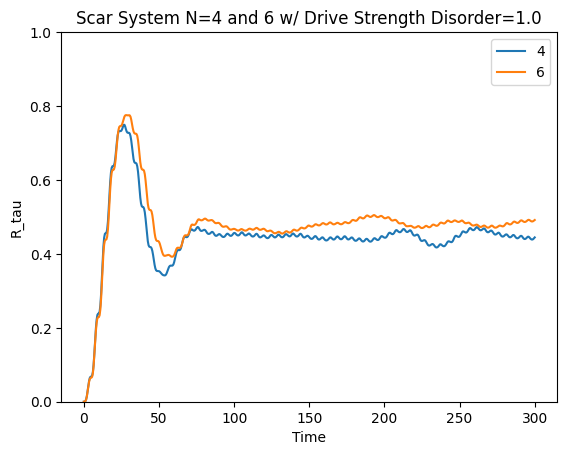

In [20]:
wd = 0.642570281124498
tlist = np.linspace(0, 300, 600)
d = 1.0
reals = 200

Rtau_scar = np.zeros(len(tlist))
for _ in range(reals):
    # scar system
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(4, random_seed=True, ds_detuning=d, random_drive_strength=True)
    args = {"A": 0.1, "omega": wd}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))
    Rtau_scar += Rtau
Rtau_plot4 = Rtau_scar / reals

Rtau_scar = np.zeros(len(tlist))
for _ in range(reals):
    # scar system
    H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(6, random_seed=True, ds_detuning=d, random_drive_strength=True)
    args = {"A": 0.1, "omega": wd}
    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues[-1] - eigenvalues[0]))
    Rtau_scar += Rtau
Rtau_plot6 = Rtau_scar / reals

plt.title(f"Scar System N={4} and {6} w/ Drive Strength Disorder={d}")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.plot(tlist, Rtau_plot4, label="4")
plt.plot(tlist, Rtau_plot6, label='6')
plt.legend()
plt.show()